<a href="https://colab.research.google.com/github/rostovcevartem209/hh_database/blob/main/hh_database_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла.

In [3]:
hh_database = pd.read_csv('/content/drive/MyDrive/hh_database.csv', sep = ';')

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [4]:
hh_database.head(3)

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

4. Обратите внимание на информацию о числе непустых значений.

In [5]:
hh_database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

5. Выведите основную статистическую информацию о столбцах.


In [6]:
hh_database.describe(include='all')

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Тюменский Государствен...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [7]:
def get_education(education):
  educ = education.split()[0:2]
  if educ[-1]=='образование':
    res = educ[0].strip().lower()
  else:
    res = ' '.join(educ).strip().lower()
  return res

hh_database_copy = hh_database.copy()
hh_database_copy['Образование'] = hh_database['Образование и ВУЗ'].apply(get_education)
hh_database_copy = hh_database_copy.drop('Образование и ВУЗ', axis = 1)
hh_database_copy.head(3)

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",12.04.2019 08:42,Не указано,высшее
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,16.04.2019 08:35,Не указано,среднее специальное


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина.
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '.
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [8]:
def get_sex(info):
  sex = info.split(' , ')[0]
  return sex[0].upper()

def get_age(info):
  age = info.split(' , ')[1].split()[0]
  return int(age)

hh_database_copy = hh_database_copy.copy()
hh_database_copy['Пол'] = hh_database_copy['Пол, возраст'].apply(get_sex)
hh_database_copy['Возраст'] = hh_database_copy['Пол, возраст'].apply(get_age)
hh_database_copy = hh_database_copy.drop('Пол, возраст', axis = 1)
hh_database_copy.head(3)

,ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст
0,29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее,М,39
1,40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",12.04.2019 08:42,Не указано,высшее,М,60
2,20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,16.04.2019 08:35,Не указано,среднее специальное,Ж,36


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**.

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [9]:
def get_experiences(info):
  if pd.isna(info) or info=='Не указано':
    return np.nan

  words = info.lower().split()[:7]
  years = 0
  months = 0
  for i, word in enumerate(words):
    if 'год' in word or 'лет' in word:
      years = int(words[i-1])
    elif 'месяц' in word:
      months = int(words[i-1])
  result = years*12+months
  return int(result)

hh_database_copy = hh_database_copy.copy()
hh_database_copy['Опыт работы (месяц)'] = hh_database_copy['Опыт работы'].apply(get_experiences)
hh_database_copy = hh_database_copy.drop('Опыт работы', axis = 1)
hh_database_copy.head(3)

,ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,Опыт работы (месяц)
0,29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...","МАОУ ""СОШ № 1 г.Немана""",Системный администратор,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее,М,39,202.0
1,40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",12.04.2019 08:42,Не указано,высшее,М,60,233.0
2,20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,ПАО Сбербанк,Кассир-операционист,16.04.2019 08:35,Не указано,среднее специальное,Ж,36,123.0


4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , …
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [10]:
def delete_metro(info):
  signs = info.split(' , ')
  if 'м.' in signs[1]:
    signs.pop(1)
    return ' , '.join(signs)
  else:
    return ' , '.join(signs)

def get_city(info):
  million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
  city = info.split(' , ')[0]
  if city == 'Москва' or city == 'Санкт-Петербург':
    return city
  elif city in million_cities:
    return 'город-миллионник'
  else:
    return 'другие'

def relocate(info):
  ready = info.split(' , ')[1]
  if 'не' in ready:
    return False
  else:
    return True

def business_trips(info):
  if len(info.split(' , '))>2:
    ready = info.split(' , ')[2]
    if 'не' in ready:
      return False
    else:
      return True
  else:
    return False

hh_database_copy = hh_database_copy.copy()
hh_database_copy['Город'] = hh_database_copy['Город, переезд, командировки'].apply(get_city)
hh_database_copy['Город, переезд, командировки'] = hh_database_copy['Город, переезд, командировки'].apply(delete_metro)
hh_database_copy['Готовность к переезду'] = hh_database_copy['Город, переезд, командировки'].apply(relocate)
hh_database_copy['Готовность к командировкам'] = hh_database_copy['Город, переезд, командировки'].apply(business_trips)
hh_database_copy = hh_database_copy.drop('Город, переезд, командировки', axis = 1)
hh_database_copy.head(3)
# hh_database_copy[hh_database_copy['Город']=='Санкт-Петербург']


,ЗП,Ищет работу на должность:,Занятость,График,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,Опыт работы (месяц),Город,Готовность к переезду,Готовность к командировкам
0,29000 руб.,Системный администратор,"частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...","МАОУ ""СОШ № 1 г.Немана""",Системный администратор,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее,М,39,202.0,другие,False,False
1,40000 руб.,Технический писатель,"частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",12.04.2019 08:42,Не указано,высшее,М,60,233.0,другие,False,True
2,20000 руб.,Оператор,полная занятость,полный день,ПАО Сбербанк,Кассир-операционист,16.04.2019 08:35,Не указано,среднее специальное,Ж,36,123.0,другие,False,False


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [11]:
def full_employment(info):
  if 'полная занятость' in info:
    return True
  else:
    return False

def part_time(info):
  if 'частичная занятость' in info:
    return True
  else:
    return False

def project(info):
  if 'проектная работа' in info:
    return True
  else:
    return False

def internship(info):
  if 'стажировка' in info:
    return True
  else:
    return False

def volunteering(info):
  if 'волонтерство' in info:
    return True
  else:
    return False

hh_database_copy['Полная занятость'] = hh_database_copy['Занятость'].apply(full_employment)
hh_database_copy['Частичная занятость'] = hh_database_copy['Занятость'].apply(part_time)
hh_database_copy['Проектная работа'] = hh_database_copy['Занятость'].apply(project)
hh_database_copy['Волонтерство'] = hh_database_copy['Занятость'].apply(volunteering)
hh_database_copy['Стажировка'] = hh_database_copy['Занятость'].apply(internship)
hh_database_copy.head(3)

,ЗП,Ищет работу на должность:,Занятость,График,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,Опыт работы (месяц),Город,Готовность к переезду,Готовность к командировкам,Полная занятость,Частичная занятость,Проектная работа,Волонтерство,Стажировка
0,29000 руб.,Системный администратор,"частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...","МАОУ ""СОШ № 1 г.Немана""",Системный администратор,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее,М,39,202.0,другие,False,False,True,True,True,False,False
1,40000 руб.,Технический писатель,"частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",12.04.2019 08:42,Не указано,высшее,М,60,233.0,другие,False,True,True,True,True,False,False
2,20000 руб.,Оператор,полная занятость,полный день,ПАО Сбербанк,Кассир-операционист,16.04.2019 08:35,Не указано,среднее специальное,Ж,36,123.0,другие,False,False,True,False,False,False,False


In [12]:
#полный день
def full_day(info):
  if 'полный день' in info:
    return True
  else:
    return False

#гибкий график
def flexible(info):
  if 'гибкий график' in info:
    return True
  else:
    return False

#сменный график
def shift(info):
  if 'сменный график' in info:
    return True
  else:
    return False

#вахтовый метод
def vachta(info):
  if 'вахтовый метод' in info:
    return True
  else:
    return False

#удаленная работа
def remote(info):
  if 'удаленная работа' in info:
    return True
  else:
    return False

hh_database_copy['Полный день'] = hh_database_copy['График'].apply(full_day)
hh_database_copy['Гибкий график'] = hh_database_copy['График'].apply(flexible)
hh_database_copy['Сменный график'] = hh_database_copy['График'].apply(shift)
hh_database_copy['Вахтовый метод'] = hh_database_copy['График'].apply(vachta)
hh_database_copy['Удаленная работа'] = hh_database_copy['График'].apply(remote)
hh_database_copy = hh_database_copy.drop('Занятость', axis = 1)
hh_database_copy = hh_database_copy.drop('График', axis = 1)
hh_database_copy.head(3)

,ЗП,Ищет работу на должность:,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,Опыт работы (месяц),...,Полная занятость,Частичная занятость,Проектная работа,Волонтерство,Стажировка,Полный день,Гибкий график,Сменный график,Вахтовый метод,Удаленная работа
0,29000 руб.,Системный администратор,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее,М,39,202.0,...,True,True,True,False,False,True,True,True,True,True
1,40000 руб.,Технический писатель,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",12.04.2019 08:42,Не указано,высшее,М,60,233.0,...,True,True,True,False,False,True,True,True,False,True
2,20000 руб.,Оператор,ПАО Сбербанк,Кассир-операционист,16.04.2019 08:35,Не указано,среднее специальное,Ж,36,123.0,...,True,False,False,False,False,True,False,False,False,False


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**.
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата,
* "proportion" - пропорция,
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования:
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [13]:
currency = pd.read_csv('/content/drive/MyDrive/ExchangeRates.csv', sep = ',')

In [14]:
def get_sum(info):
  sum = info.split()[0]
  return int(sum)

def get_cur(info):
  cur = info.split()[1][:]
  return cur

def normalized_cur(info):
  normalized_cur = {
      'руб.': 'руб.',
      'грн.': 'UAH',
      'USD': 'USD',
      'EUR': 'EUR',
      'бел.руб.': 'BYN',
      'KGS': 'KGS',
      'сум': 'UZS',
      'AZN': 'AZN',
      'KZT': 'KZT'
  }
  return normalized_cur[info]

#первод в формат даты
currency['date'] = pd.to_datetime(currency['date'], errors = 'coerce')
hh_database_copy['Обновление резюме'] = pd.to_datetime(hh_database_copy['Обновление резюме'], errors = 'coerce')
hh_database_copy['Обновление резюме'] = hh_database_copy['Обновление резюме'].dt.date
hh_database_copy['Обновление резюме'] = pd.to_datetime(hh_database_copy['Обновление резюме'], errors = 'coerce')

#выделение суммы и преобразование валюты
hh_database_copy['Сумма ЗП'] = hh_database_copy['ЗП'].apply(get_sum)
hh_database_copy['Валюта'] = hh_database_copy['ЗП'].apply(get_cur)
hh_database_copy['Валюта'] = hh_database_copy['Валюта'].apply(normalized_cur)

#объединение таблиц
currency_copy = currency.copy()
currency_copy.rename(columns={
    'currency': 'Валюта',
    'date': 'Обновление резюме'
}, inplace=True)

db_curr = hh_database_copy.merge(currency_copy,
                                  on = ['Валюта', 'Обновление резюме'],
                                  how = 'left')

#заполнение пропусков и результирующего столбца
db_curr['close'] = db_curr['close'].fillna(1)
db_curr['proportion'] = db_curr['proportion'].fillna(1)
db_curr['ЗП (руб)'] = db_curr['Сумма ЗП'] * db_curr['close'] / db_curr['proportion']
db_curr = db_curr.drop(['Сумма ЗП', 'Валюта', 'per', 'time', 'close', 'vol', 'proportion', 'ЗП'], axis = 1)
db_curr[db_curr['ЗП (руб)']%10 != 0].head(5)

/tmp/ipykernel_490/1720466667.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  currency['date'] = pd.to_datetime(currency['date'], errors = 'coerce')
/tmp/ipykernel_490/1720466667.py:25: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  hh_database_copy['Обновление резюме'] = pd.to_datetime(hh_database_copy['Обновление резюме'], errors = 'coerce')


,Ищет работу на должность:,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,Опыт работы (месяц),Город,...,Частичная занятость,Проектная работа,Волонтерство,Стажировка,Полный день,Гибкий график,Сменный график,Вахтовый метод,Удаленная работа,ЗП (руб)
30,Engineer,Outsourcing,Data Engineer,2019-04-26,Не указано,высшее,Ж,31,98.0,другие,...,False,False,False,False,True,False,False,False,False,91896.000
81,"Системный администратор, веб-программист",Sailet,Менеджер по управлению проектами,2019-04-22,Не указано,неоконченное высшее,М,20,23.0,другие,...,False,False,False,False,True,False,False,False,False,26988.800
85,Программист 1C,Московский финансово-промышленный университет ...,Программист 1с,2019-04-11,Не указано,высшее,М,38,157.0,Москва,...,False,False,False,False,True,False,False,False,False,139999.000
126,"Программист, Инженер-системотехник, Водитель, ...","ТОО ""Идальго Актау"" Мебельный салон ""Prestige""",сборщик мебели,2019-04-26,Не указано,высшее,М,32,130.0,другие,...,False,False,False,False,True,True,False,True,False,36922.767
145,"Координатор проектов, редактор",отдельные проекты,"координатор/ администратор, коммуникации/ сопр...",2019-05-13,Не указано,высшее,Ж,33,160.0,Москва,...,True,True,False,False,True,True,False,False,True,146177.600


# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

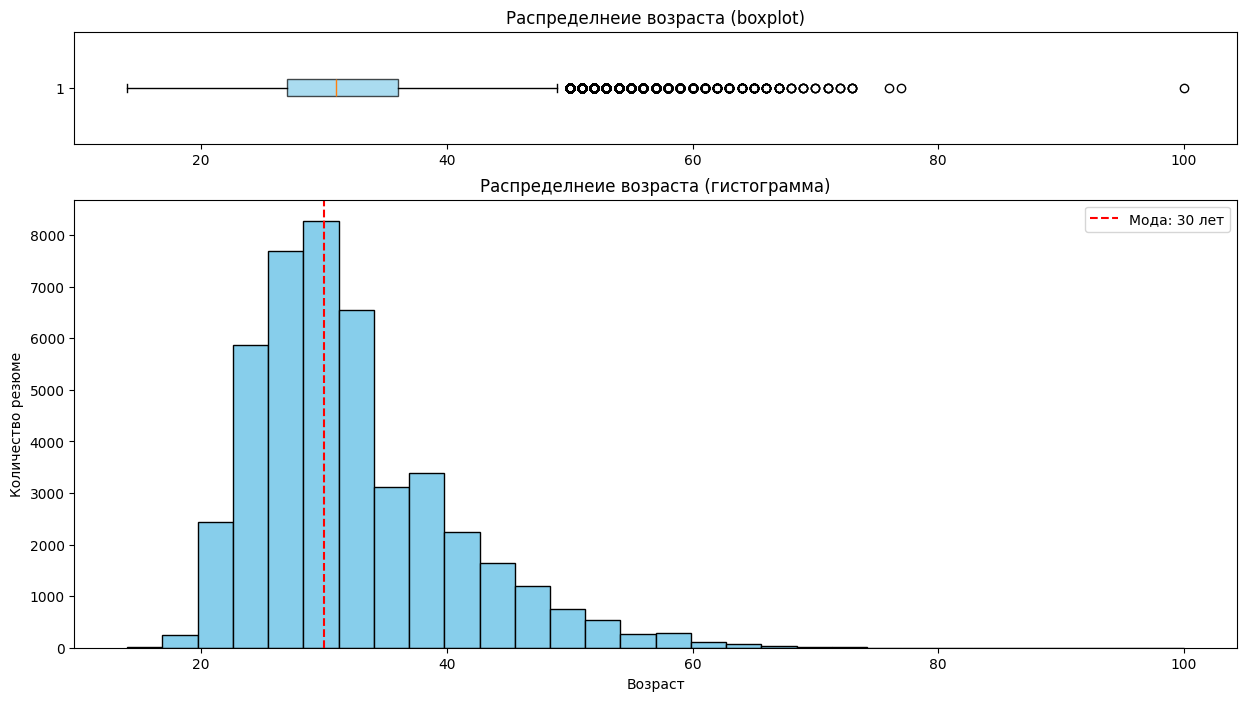

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,8), gridspec_kw={'height_ratios': [1, 4]})


axes[0].boxplot(db_curr['Возраст'],
                vert = False,
                patch_artist=True,
                boxprops = dict(facecolor='skyblue',alpha = 0.7),
                )
axes[0].set_title('Распределнеие возраста (boxplot)')

axes[1].hist(db_curr['Возраст'],
             bins = 30,
             color = 'skyblue',
             edgecolor = 'black')

axes[1].axvline(db_curr['Возраст'].mode()[0],
                color = 'red',
                linestyle = '--',
                label = f'Мода: {db_curr['Возраст'].mode()[0]} лет')
axes[1].set_title('Распределнеие возраста (гистограмма)')
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('Количество резюме')

axes[1].legend()
plt.show()

Мода распределения возраста составляет 30 лет. Большинство соискателей находятся в возрастном интервале от 25 до 35 лет. Основная масса данных сосредоточена в границах от 14 до 50 лет; значения от 50 до 75 лет имеют значительно меньшую частоту и отображаются как выбросы. Значение в 100 лет является явной аномалией в данных

2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

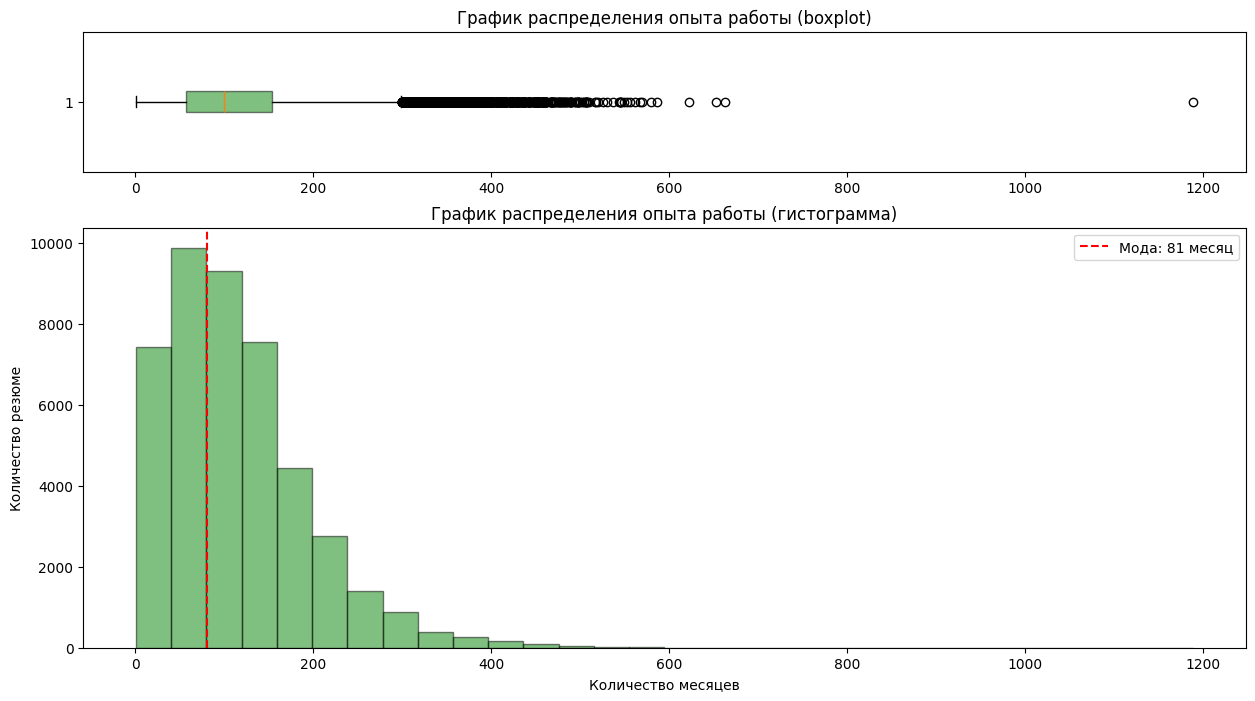

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,8), gridspec_kw={'height_ratios': [1, 3]})


experience = db_curr['Опыт работы (месяц)'].dropna()
axes[0].boxplot(experience,
                vert = False,
                patch_artist=True,
                boxprops = dict(facecolor='green',alpha = 0.5),
                )
axes[0].set_title('График распределения опыта работы (boxplot)')

axes[1].hist(experience,
             color = 'green',
             bins = 30,
             edgecolor = 'black',
             alpha = 0.5)
axes[1].axvline(experience.mode()[0],
                color = 'red',
                linestyle = '--',
                label = f'Мода: {int(experience.mode()[0])} месяц')
axes[1].set_title('График распределения опыта работы (гистограмма)')
axes[1].set_xlabel('Количество месяцев')
axes[1].set_ylabel('Количество резюме')
axes[1].legend()

plt.show()

Самый частовстречаемый опыт работы в резюме - 81 месяц, предельные значения признака от 0 до 600, значение в 1200 месяцев предположительно является аномалией. Большинство соискателей указало опыт в диапазоне от 0 до 170 месяцев.


3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


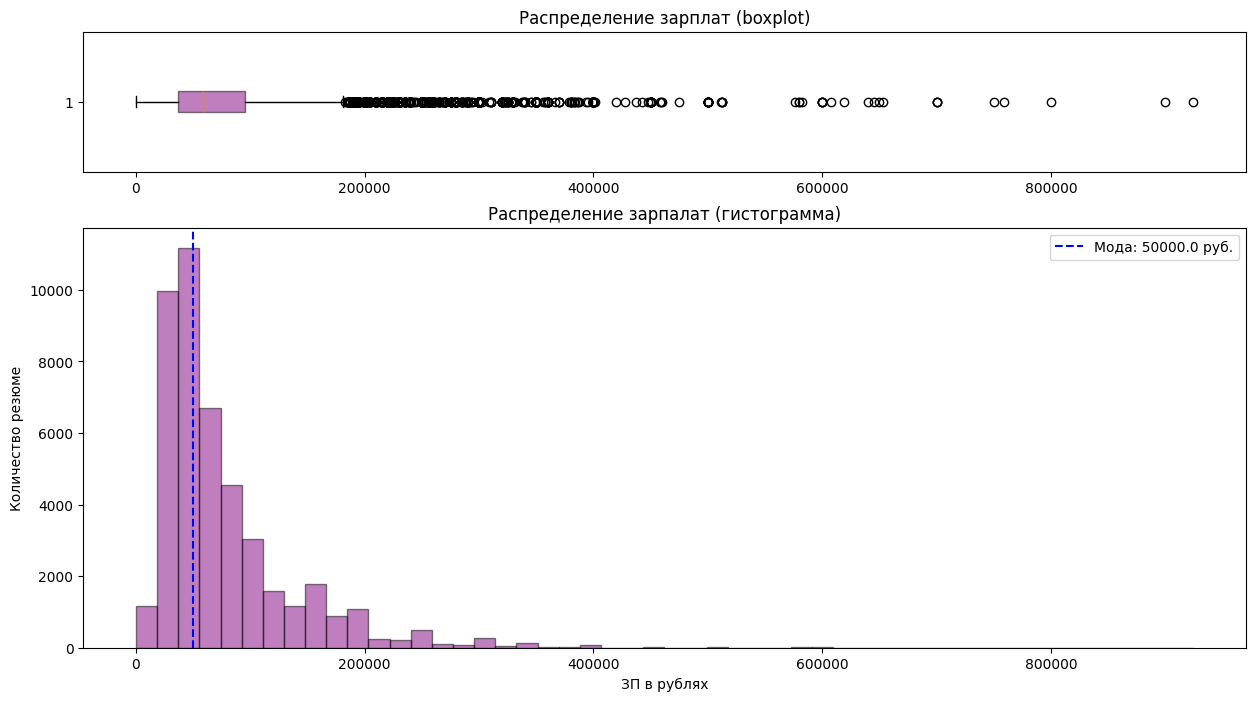

In [17]:
from IPython.terminal.embed import line_magic
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,8), gridspec_kw={'height_ratios': [1,3]})

salary = db_curr['ЗП (руб)'].dropna()
salary_filtred = salary[salary<1_000_000]

axes[0].boxplot(salary_filtred,
                vert=False,
                patch_artist=True,
                boxprops=dict(facecolor='purple',alpha=0.5))
axes[0].set_title('Распределение зарплат (boxplot)')

axes[1].hist(
    salary_filtred,
    bins = 50,
    color = 'purple',
    edgecolor = 'black',
    alpha = 0.5
)
axes[1].axvline(
    salary_filtred.mode()[0],
    color = 'blue',
    linestyle = '--',
    label = f'Мода: {salary_filtred.mode()[0]} руб.'
)
axes[1].set_title('Распределение зарпалат (гистограмма)')
axes[1].set_xlabel('ЗП в рублях')
axes[1].set_ylabel('Количество резюме')
plt.legend()

plt.show()

Так как в данных встречаются огормные аномалии графики становятся неинформативными. Значения были отфлиьтрованы (ограничение в 1 млн. руб.). Выводы по графикам: Больше всего соискателей указало зарплату в 50 тыс. руб; предельные значения признака я бы указал от 0 до 420 тыс. остальные значения сильно завышены и могут быть аномальными. Большинство соискателей указывают зарплату от 30 до 100 тыс. руб. В данных были обнаружены гигантские размеры заработной платы (20+ млн. руб.) такие значения можно считать аномальными.

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

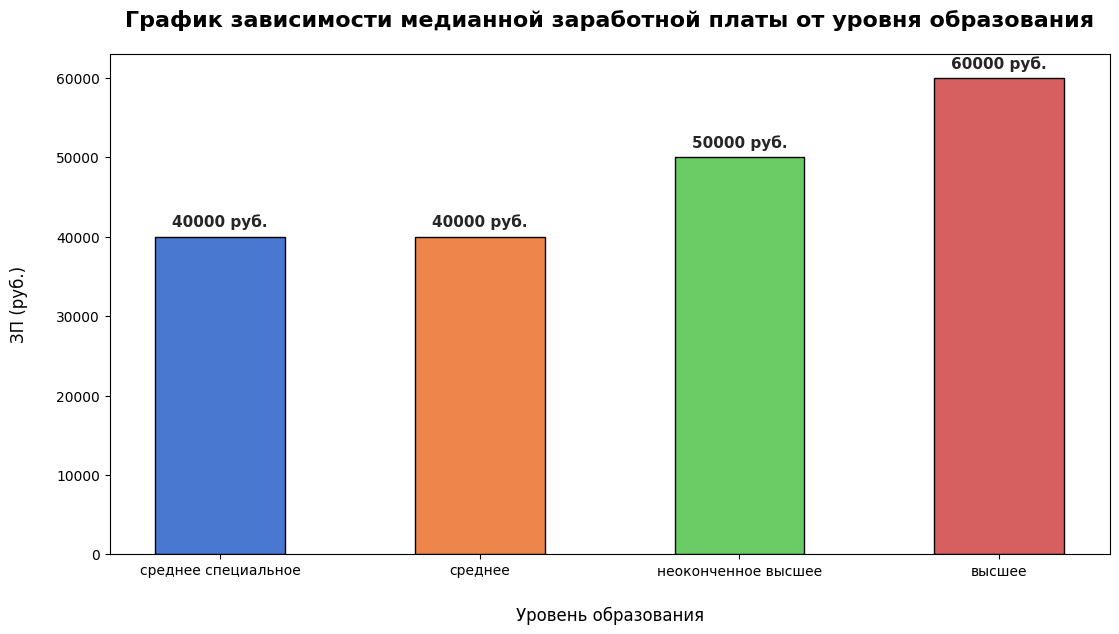

In [18]:
grouped_education = db_curr[db_curr['ЗП (руб)']<1_000_000].groupby('Образование', as_index=False)['ЗП (руб)'].median()
grouped_education = grouped_education.sort_values(by='ЗП (руб)')

fig = plt.figure(figsize=(10,5))
ax = fig.add_axes([0,0,1,1])

sns.set_theme(style="whitegrid")

bars = ax.bar(
    x = grouped_education['Образование'],
    height = grouped_education['ЗП (руб)'],
    color = sns.color_palette('muted', len(grouped_education)),
    edgecolor = 'black',
    linewidth = 1,
    width = 0.5
)

#подписи к осям и заголовок
ax.set_title('График зависимости медианной заработной платы от уровня образования',fontsize = 16, fontweight = 'bold', pad = 20)
ax.set_ylabel('ЗП (руб.)', fontsize = 12, labelpad = 20)
ax.set_xlabel('Уровень образования', fontsize = 12, labelpad = 20)

#подписи к столбцам
for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{int(height)} руб.',
      xy = (bar.get_x() + bar.get_width()/2, height),
      xytext = (0, 5) ,
      textcoords = 'offset points',
      ha = 'center',
      va = 'bottom',
      fontsize = 11,
      fontweight = 'bold'
  )


plt.show()


Наибольшая заработная плата наблюдается у соискателей с высшим образованием, наименьшая у людей с средним и средним специальным образованием. Уровень образовния безусловно важен для прогнозирования заработной платы, т.к различие серьезное и состоявляет 20 тыс. руб.

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

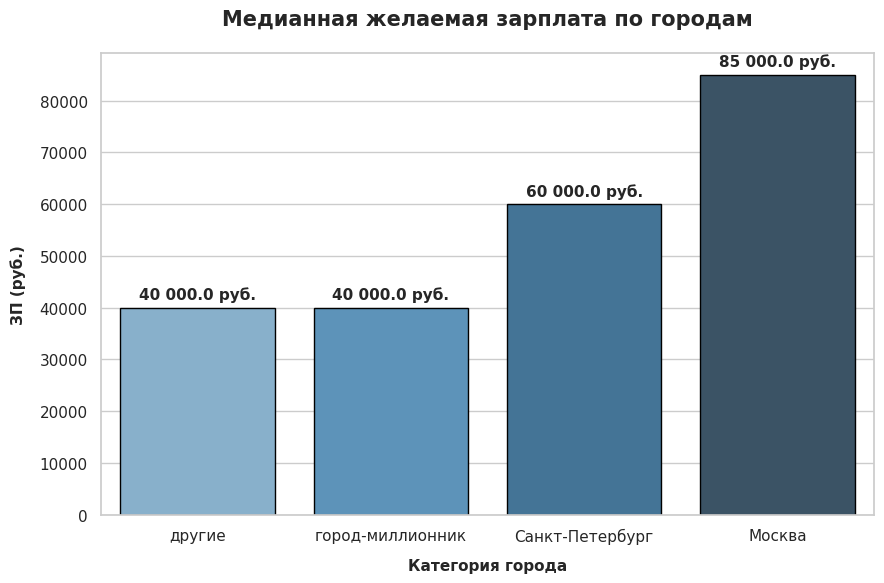

In [19]:
grouped_city = db_curr[db_curr['ЗП (руб)']<1_000_000].groupby(by='Город',as_index=False)['ЗП (руб)'].median()
grouped_city = grouped_city.sort_values(by='ЗП (руб)')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=grouped_city,
    x = 'Город',
    y='ЗП (руб)',
    palette='Blues_d',
    hue = 'Город',
    edgecolor = 'black',
    legend=False
)

for container in ax.containers:
  ax.bar_label(
      container,
      fmt=lambda x: f'{x:,}'.replace(',',' ') + ' руб.',
      label_type = 'edge',
      fontsize = 11,
      fontweight = 'bold',
      padding=4
  )

plt.title('Медианная желаемая зарплата по городам', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Категория города', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('ЗП (руб.)', fontsize=11, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.show()

Наибольшая медианная заработная плата наблюдается у соискателей из Москвы, на втором месте - жители Санкт-Петербурга, желаемая заработная плата в городах-миллиониках и других городах не отличается.
 Признак города будет играть важную роль в прогнозировании целевой переменной (желаемой зарплаты), поскольку разница между максимальным показателем (Москва) и минимальным («другие» города) является существенной и составляет более чем 2 раза

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

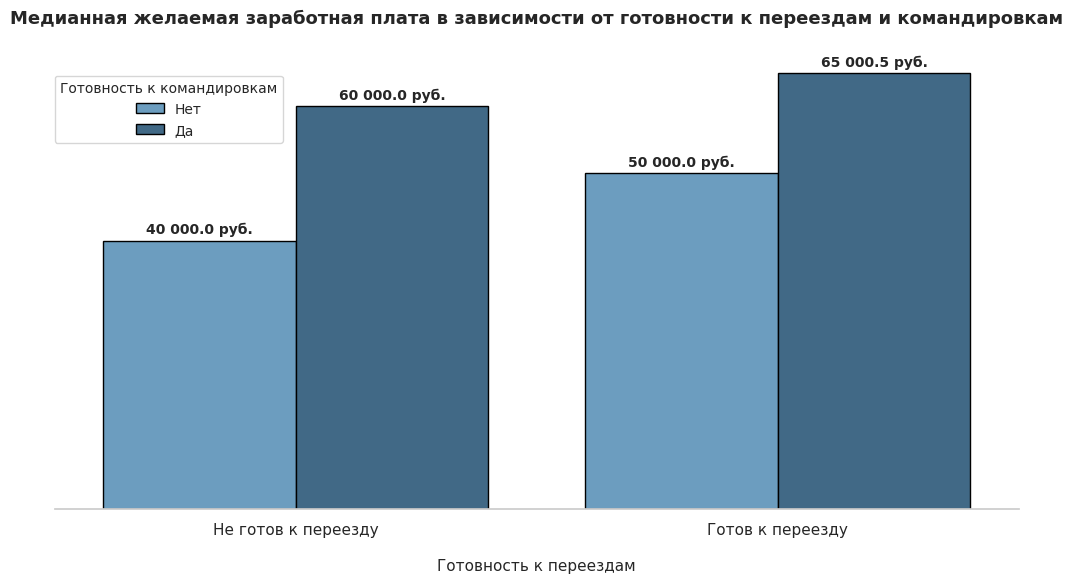

In [20]:
grouped_ready = db_curr[db_curr['ЗП (руб)']<1_000_000].groupby(by=['Готовность к переезду','Готовность к командировкам'], as_index=False)['ЗП (руб)'].median()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))


ax = sns.barplot(
    data=grouped_ready,
    x = 'Готовность к переезду',
    y='ЗП (руб)',
    palette='Blues_d',
    hue = 'Готовность к командировкам',
    edgecolor = 'black'
)

for container in ax.containers:
  ax.bar_label(
      container,
      fmt = lambda x: f'{x:,}'.replace(',',' ') + ' руб.',
      label_type='edge',
      fontsize=10,
      fontweight='bold',
      padding = 3
  )

sns.despine(left=True)
plt.yticks([])
plt.ylabel('')

plt.title('Медианная желаемая заработная плата в зависимости от готовности к переездам и командировкам',
          fontsize=13,
          fontweight='bold',
          pad=20)
plt.xlabel('Готовность к переездам',
           fontsize=11,
           labelpad=15)
plt.xticks(ticks=[0,1], labels=['Не готов к переезду', 'Готов к переезду'], fontsize=11)

sns.move_legend(
    ax,
    labels = ['Нет', 'Да'],
    loc=[0,0.8],
    title='Готовность к командировкам',
    fontsize='small',
    title_fontsize='small'
)

plt.tight_layout()
plt.show()

По графику видно, что соискатели, готовые к переезду, просят более высокую заработную плату (медиана возрастает на 10–15 тыс. рублей). Также заметно, что уровень желаемой ЗП у людей, не готовых к командировкам, существенно ниже, чем у тех, кто к ним готов.

Заметно, что готовность к командировкам оказывает более сильное влияние на зарплатные ожидания, чем готовность к переезду. Так, соискатели, готовые только к командировкам, в медиане просят 60 000 руб., в то время как готовые только к переезду — 50 000 руб.

В целом, общая мобильность соискателя (готовность и к переезду, и к командировкам) ожидаемо предполагает самую высокую медианную заработную плату — 65 000 руб.

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

/tmp/ipykernel_490/772368479.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_educ = db_curr.pivot_table(


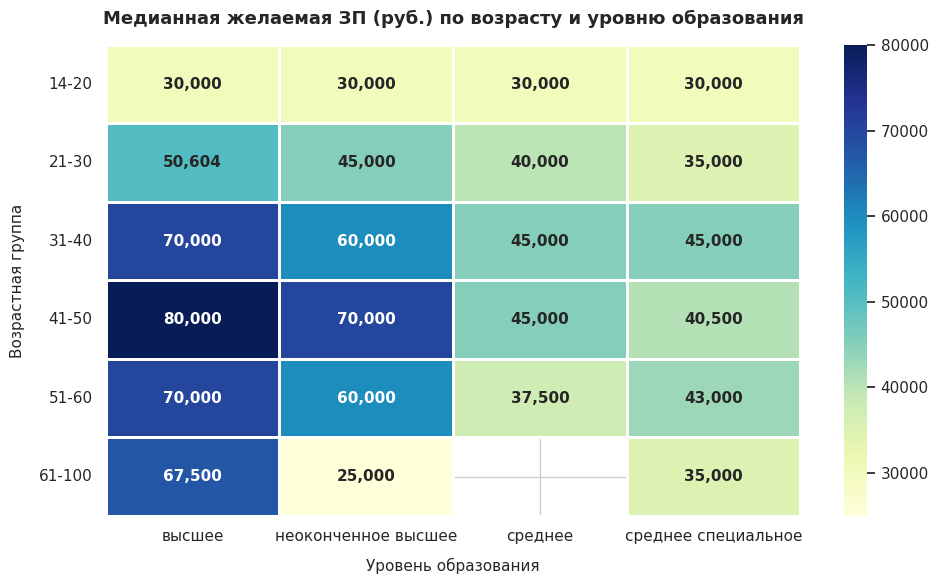

In [21]:
# т.к разброс возрастов очень большой тепловая карта становится трудной для восприятия, разделим возраста по группам

db_curr['Возрастная группа'] = pd.cut(
    db_curr['Возраст'],
    bins=[13,20,30,40,50,60,100],
    labels=['14-20', '21-30', '31-40', '41-50', '51-60', '61-100']
)


age_educ = db_curr.pivot_table(
    values='ЗП (руб)',
    index='Возрастная группа',
    columns='Образование',
    aggfunc='median',
    fill_value=np.nan
)


plt.figure(figsize=(10,6))

ax=sns.heatmap(
    data=age_educ,
    cmap='YlGnBu',
    annot=True,
    fmt=',.0f',
    linewidths=1,
    annot_kws={'size': 11, 'weight':'bold'}
)

plt.title('Медианная желаемая ЗП (руб.) по возрасту и уровню образования',
          fontsize=13,
          fontweight='bold',
          pad=15)
plt.xlabel('Уровень образования',
           fontsize=11,
           labelpad=10)
plt.ylabel('Возрастная группа',
           fontsize=11,
           labelpad=10)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

По тепловой карте видно, что наибольшая медианная желаемая заработная плата наблюдается у возрастной группы 41–50 лет с высшим образованием (80 тыс. руб.), что соответствует пику профессионального опыта.

В целом, уровень образования существенно влияет на зарплатные ожидания: соискатели с высшим образованием во всех категориях от 21 года просят ощутимо больше. Однако у группы 14–20 лет медиана стабильна на уровне 30 тыс. руб. независимо от образования — вероятнее всего, это стартовые позиции без опыта работы.

Также стоит отметить, что после 50 лет наблюдается постепенный спад зарплатных ожиданий, а наибольший разрыв между высшим и средне-специальным образованием достигается именно в возрасте 31–50 лет (до 2 раз).

8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

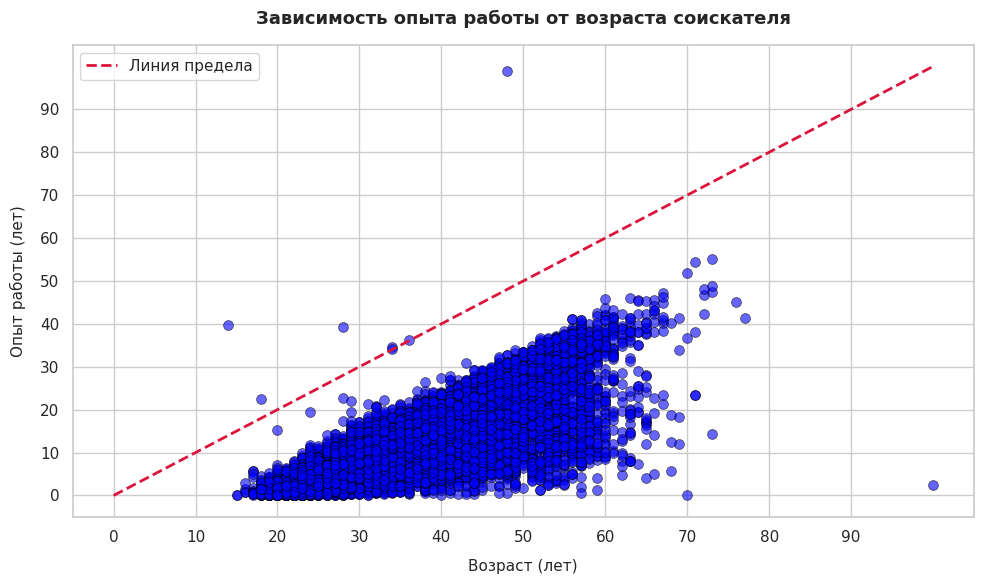

In [58]:
db_curr_copy = db_curr.copy()
db_curr_copy['Опыт работы (лет)'] = (db_curr_copy['Опыт работы (месяц)']/12).round(1)

sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))

ax = sns.scatterplot(
    data = db_curr_copy,
    x='Возраст',
    y='Опыт работы (лет)',
    alpha = 0.6,
    color='blue',
    edgecolor='black',
    s=50
)

plt.plot([0,100], [0,100],
         color='crimson',
         linestyle='--',
         linewidth=2,
         label='Линия предела')

plt.xticks(range(0,100,10))
plt.yticks(range(0,100,10))

plt.title('Зависимость опыта работы от возраста соискателя',
          fontsize=13,
          fontweight='bold',
          pad=15)
plt.xlabel('Возраст (лет)',
           fontsize=11,
           labelpad=10)
plt.ylabel('Опыт работы (лет)',
           fontsize=11,
           labelpad=10)

plt.legend()
plt.tight_layout()
plt.show()

На диаграмме рассеяния отчетливо прослеживается ожидаемый естественный рост опыта работы с увеличением возраста соискателей. Линия предела (Y = X) помогает наглядно выявить аномалии в данных: Присутствуют критические выбросы выше линии предела (например, соискатель в возрасте около 48 лет с указанным опытом 100 лет, а также кандидат 14 лет с опытом 40 лет) — это явные ошибки заполнения резюме.Встречается выброс по возрасту (соискатель 100 лет с опытом 2–3 года).Также на графике видно уплотнение точек у нижней границы (опыт от 0 до 3 лет) во всех возрастных группах, включая зрелый возраст (40+ лет). Это свидетельствует о том, что соискатели нередко сменяют сферу деятельности и начинают карьеру с нуля в зрелом возрасте.

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


In [23]:
# ваш код здесь

ваши выводы здесь

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их.

In [24]:
# ваш код здесь

2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах.

In [25]:
# ваш код здесь

3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [26]:
# ваш код здесь

4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [27]:
# ваш код здесь

5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [28]:
# ваш код здесь

6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

In [29]:
# ваш код здесь

ваш коммментарий здесь